# Particle Classification using Compact Convolutional Transformers (CCT)

<div align="center">
  <img src="https://i.postimg.cc/wj0FdNkN/CCT.png" width="800"/>
  <p><i>CCT Architecture: Combining Convolutional Tokenization with Transformer Encoders</i></p>
</div>

---

## Overview

This notebook implements a **Compact Convolutional Transformer (CCT)** for binary particle classification (Photon vs. Electron) using calorimeter images from high-energy physics experiments.

### Why CCT Instead of Standard ViT?

**Compact Convolutional Transformers** (Hassani et al., 2021) are specifically designed for **small datasets** where standard Vision Transformers struggle:

| Feature | Standard ViT | CCT (This Notebook) |
|---------|-------------|---------------------|
| **Tokenization** | Fixed patch embedding | Convolutional layers |
| **Inductive Bias** | Minimal | Strong (via convolutions) |
| **Positional Encoding** | Required | Optional |
| **Pooling** | CLS token | Sequence pooling |
| **Data Efficiency** | Needs large datasets | Works with small datasets |
| **Parameters** | ~4.7M (CIFAR-10) | ~0.4M (smaller) |

### Key CCT Components

1. **Convolutional Tokenizer**: Replaces patch embedding with conv layers → better spatial features
2. **Sequence Pooling**: Attention-based aggregation instead of CLS token → more efficient
3. **Stochastic Depth**: Regularization technique for better generalization
4. **Optional Positional Embeddings**: Convolutions provide spatial information naturally

### Dataset

- **Particle Types**: Single Photon (Pt 50 GeV) vs. Single Electron (Pt 50 GeV)
- **Image Size**: 32×32 pixels
- **Channels**: 2 (Energy deposits + Timing information)
- **Total Samples**: ~249k images
- **Challenge**: Small dataset for transformer architectures → CCT is ideal

### Architecture Pipeline
```
Input (32×32×2)
↓
[Convolutional Tokenizer]  ← Conv layers + pooling (8×8 = 64 tokens)
↓
[Linear Projection]  ← Project to embedding dimension
↓
[Positional Encoding]  ← Optional learnable embeddings
↓
[Transformer Encoder × N]  ← Multi-head attention + MLP + Stochastic Depth
↓
[Sequence Pooling]  ← Attention-based aggregation
↓
[Classification Head]  ← MLP layers → Binary output
↓
Output (Photon/Electron)
```

### References

- **Paper**: [Escaping the Big Data Paradigm with Compact Transformers](https://arxiv.org/abs/2104.05704) (Hassani et al., 2021)
- **Keras Example**: [Compact Convolutional Transformers](https://keras.io/examples/vision/cct/)
- **GitHub**: [SHI-Labs/Compact-Transformers](https://github.com/SHI-Labs/Compact-Transformers)

---

### Quick Start

Run all cells sequentially. The notebook includes:
- Data loading from Google Drive
- Optimized CCT architecture for 32×32×2 images
- Training with mixed precision (AMP)
- Comprehensive evaluation and visualization

---

<div align="center">
  <b>ML4Sci DeepLearn Hackathon - Particle Images Challenge</b><br>
</div>

In [1]:
# ============================================================================
# Imports and Setup
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from tqdm.auto import tqdm
import h5py
import gc
import random
from pathlib import Path

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.06 GB


In [2]:
# ============================================================================
# Configuration
# ============================================================================
import os

class Config:
    """Optimized configuration for 32x32x2 particle data"""

    # Data parameters
    image_size = 32
    in_channels = 2  # Energy + Timing
    num_classes = 1  # Binary classification

    # CCT Architecture parameters
    # Convolutional Tokenizer parameters
    conv_layers = 2  # Number of conv layers in tokenizer
    conv_kernel_size = 3
    conv_stride = 1
    conv_padding = 1
    pooling_kernel_size = 3
    pooling_stride = 2
    num_output_channels = [64, 128]  # Channels for each conv layer
    
    # After 2 conv+pool layers: 32 -> 16 -> 8 (8x8 spatial dim)
    # Number of tokens/patches
    num_patches = 64  # 8x8 = 64 tokens
    
    # Transformer parameters
    projection_dim = 128  # Token projection dimension
    embed_dim = 128  # Keep same as projection_dim for CCT
    num_heads = 4  # Multi-head attention heads
    num_layers = 6  # Transformer encoder layers
    mlp_ratio = 4  # MLP hidden dim = embed_dim * mlp_ratio
    dropout = 0.15
    attention_dropout = 0.1
    stochastic_depth_rate = 0.05  # For stochastic depth regularization
    
    # Positional embedding (optional in CCT)
    use_positional_embedding = True
    
    # Sequence pooling (replaces CLS token)
    use_sequence_pooling = True

    # MLP head
    mlp_head_hidden = [512, 256]

    # Training parameters
    batch_size = 64
    num_epochs = 100
    learning_rate = 5e-4
    weight_decay = 1e-4
    warmup_epochs = 5

    # Optimization
    label_smoothing = 0.1
    gradient_clip = 1.0

    # Data augmentation
    use_augmentation = True
    energy_scale_range = (0.9, 1.1)
    noise_std = 0.01

    # Mixed precision training
    use_amp = True

    # Paths (Using Google Drive)
    base_dir = '/content/drive/MyDrive/Colab Notebooks/Particle_Images/CCT'
    data_path = f'/content/drive/MyDrive/Colab Notebooks/Particle_Images/data'
    checkpoint_dir = f'{base_dir}/checkpoints'

    def __repr__(self):
        return '\n'.join([f'{k}: {v}' for k, v in self.__dict__.items() if not k.startswith('_')])

config = Config()

# Create checkpoint directory if it doesn't exist
os.makedirs(config.checkpoint_dir, exist_ok=True)

print("Configuration:")
print(config)

Configuration:



In [3]:
# ============================================================================
# Data Loading from Google Drive
# ============================================================================

def load_data_from_h5(photon_path, electron_path):
    """
    Load particle physics data efficiently
    """
    print("Loading photon data to check size...")
    with h5py.File(photon_path, 'r') as f:
        # Get shape without loading data
        p_shape = f['X'].shape
        p_len = p_shape[0]

    print("Loading electron data to check size...")
    with h5py.File(electron_path, 'r') as f:
        e_shape = f['X'].shape
        e_len = e_shape[0]

    total_len = p_len + e_len
    print(f"Total samples: {total_len}")

    # Pre-allocate memory for the combined dataset
    X = np.empty((total_len, 32, 32, 2), dtype=np.float32)
    y = np.empty((total_len,), dtype=np.float32)

    # Load Photons directly into the pre-allocated array
    print("Reading photon data...")
    with h5py.File(photon_path, 'r') as f:
        f['X'].read_direct(X, dest_sel=np.s_[:p_len])
    y[:p_len] = 0

    # Load Electrons directly into the pre-allocated array
    print("Reading electron data...")
    with h5py.File(electron_path, 'r') as f:
        f['X'].read_direct(X, dest_sel=np.s_[p_len:])
    y[p_len:] = 1

    # Shuffle indices instead of the whole array to save memory
    indices = np.arange(total_len)
    np.random.shuffle(indices)

    X = X[indices]
    y = y[indices]

    gc.collect()
    return X, y

In [4]:
# ============================================================================
# Load Data from Kaggle Input
# ============================================================================
import os

# Define the Kaggle input directory
data_dir = '/kaggle/input/electron-photon-dataset'

# (Optional) Check the exact filenames in the directory to be sure
print("Files found in dataset:", os.listdir(data_dir))

# Define paths to the specific files
# NOTE: If the filenames printed above are different, update them here!
photon_path = f"{data_dir}/SinglePhotonPt50_IMGCROPS_n249k_RHv1.hdf5"
electron_path = f"{data_dir}/SingleElectronPt50_IMGCROPS_n249k_RHv1.hdf5"

# Load the data using the optimized function
# (Make sure you have run the cell defining 'load_data_from_h5' first!)
X_full, y_full = load_data_from_h5(photon_path, electron_path)

# Verify shapes
print(f"Loaded X_full shape: {X_full.shape}")
print(f"Loaded y_full shape: {y_full.shape}")

Files found in dataset: ['SinglePhotonPt50_IMGCROPS_n249k_RHv1.hdf5', 'SingleElectronPt50_IMGCROPS_n249k_RHv1.hdf5']
Loading photon data to check size...
Loading electron data to check size...
Total samples: 498000
Reading photon data...
Reading electron data...
Loaded X_full shape: (498000, 32, 32, 2)
Loaded y_full shape: (498000,)


In [5]:
# ============================================================================
# Data Preprocessing and Normalization
# ============================================================================

def normalize_data(X_train, X_val=None, X_test=None):
    """
    Normalize data to zero mean and unit variance
    Calculate statistics on training set and apply to all sets
    """
    # Calculate mean and std on training set
    mean = X_train.mean(axis=(0, 1, 2), keepdims=True)
    std = X_train.std(axis=(0, 1, 2), keepdims=True) + 1e-7

    print(f"Training mean: {mean.squeeze()}")
    print(f"Training std: {std.squeeze()}")

    # Normalize
    X_train_norm = (X_train - mean) / std

    results = [X_train_norm, mean, std]

    if X_val is not None:
        X_val_norm = (X_val - mean) / std
        results.append(X_val_norm)

    if X_test is not None:
        X_test_norm = (X_test - mean) / std
        results.append(X_test_norm)

    return results

In [6]:
# Train/Val/Test split (70/15/15)
n_samples = len(X_full)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)

X_train = X_full[:n_train]
y_train = y_full[:n_train]

X_val = X_full[n_train:n_train+n_val]
y_val = y_full[n_train:n_train+n_val]

X_test = X_full[n_train+n_val:]
y_test = y_full[n_train+n_val:]

print(f"Train samples: {len(X_train)}")
print(f"Val samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

del X_full, y_full
gc.collect()

# Normalize data
X_train, mean, std, X_val, X_test = normalize_data(X_train, X_val, X_test)

print(f"\nNormalized train stats:")
print(f"Mean: {X_train.mean(axis=(0,1,2))}")
print(f"Std: {X_train.std(axis=(0,1,2))}")

Train samples: 348600
Val samples: 74700
Test samples: 74700
Training mean: [ 0.00115364 -0.00024298]
Training std: [0.02361191 0.06683331]

Normalized train stats:
Mean: [ 7.343945e-04 -8.085455e-05]
Std: [0.9999372 0.9992754]


In [7]:
# ============================================================================
# Dataset and DataLoader with Physics-Appropriate Augmentation
# ============================================================================

class ParticleDataset(Dataset):
    """Dataset for particle physics calorimeter images"""

    def __init__(self, images, labels, augment=False, config=None):
        """
        Args:
            images: numpy array of shape (N, H, W, C)
            labels: numpy array of shape (N,)
            augment: whether to apply augmentation
            config: configuration object
        """
        # Convert from (N, H, W, C) to (N, C, H, W) for PyTorch
        self.images = torch.from_numpy(images).permute(0, 3, 1, 2).float()
        self.labels = torch.from_numpy(labels).float()
        self.augment = augment
        self.config = config or Config()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.augment:
            image = self.augment_image(image)

        return image, label

    def augment_image(self, image):
        """
        Physics-appropriate augmentations:
        - Rotations by 90° (respects detector symmetry)
        - Flips (respects detector symmetry)
        - Energy scaling (simulates calibration variations)
        - Noise addition (simulates detector noise)
        """
        # Random rotation by 90° multiples
        if random.random() > 0.5:
            k = random.randint(1, 3)  # 90°, 180°, or 270°
            image = torch.rot90(image, k, dims=[1, 2])

        # Random horizontal flip
        if random.random() > 0.5:
            image = torch.flip(image, dims=[2])

        # Random vertical flip
        if random.random() > 0.5:
            image = torch.flip(image, dims=[1])

        # Energy scaling (only on energy channel - channel 0)
        if random.random() > 0.5:
            scale = random.uniform(*self.config.energy_scale_range)
            image[0] = image[0] * scale

        # Add Gaussian noise (detector noise simulation)
        if random.random() > 0.5:
            noise = torch.randn_like(image) * self.config.noise_std
            image = image + noise

        return image

In [8]:
# Create datasets
train_dataset = ParticleDataset(X_train, y_train, augment=True, config=config)
val_dataset = ParticleDataset(X_val, y_val, augment=False, config=config)
test_dataset = ParticleDataset(X_test, y_test, augment=False, config=config)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test dataloader
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"Images: {sample_batch[0].shape}")  # Should be [batch_size, 2, 32, 32]
print(f"Labels: {sample_batch[1].shape}")  # Should be [batch_size]

Train batches: 5447
Val batches: 1168
Test batches: 1168

Sample batch shapes:
Images: torch.Size([64, 2, 32, 32])
Labels: torch.Size([64])


In [9]:
# ============================================================================
# CCT Tokenizer (Convolutional Tokenization)
# ============================================================================

class CCTTokenizer(nn.Module):
    """
    Convolutional tokenizer for CCT
    Replaces standard patch embedding with convolutional layers
    Provides better inductive bias for vision tasks
    """
    def __init__(
        self,
        kernel_size=3,
        stride=1,
        padding=1,
        pooling_kernel_size=3,
        pooling_stride=2,
        num_conv_layers=2,
        num_output_channels=[64, 128],
        in_channels=2,
        **kwargs
    ):
        super().__init__()
        
        # Build convolutional tokenizer
        self.conv_layers = nn.ModuleList()
        
        input_channels = in_channels
        for i in range(num_conv_layers):
            # Conv layer
            conv = nn.Conv2d(
                input_channels,
                num_output_channels[i],
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False
            )
            
            # Batch norm
            bn = nn.BatchNorm2d(num_output_channels[i])
            
            # Activation
            act = nn.ReLU(inplace=True)
            
            # MaxPooling
            pool = nn.MaxPool2d(
                kernel_size=pooling_kernel_size,
                stride=pooling_stride,
                padding=1
            )
            
            self.conv_layers.append(nn.Sequential(conv, bn, act, pool))
            input_channels = num_output_channels[i]
        
        self.output_channels = num_output_channels[-1]
    
    def forward(self, x):
        """
        Input: (B, in_channels, H, W)  e.g., (B, 2, 32, 32)
        Output: (B, num_patches, output_channels)  e.g., (B, 64, 128)
        
        After 2 conv+pool layers with stride=2 pooling:
        32 -> 16 -> 8, so we get 8x8 = 64 spatial positions
        """
        # Apply convolutional layers
        for conv_layer in self.conv_layers:
            x = conv_layer(x)
        
        # x shape: (B, C, H', W') where H'=W'=8 for our config
        B, C, H, W = x.shape
        
        # Flatten spatial dimensions to create sequence
        # (B, C, H, W) -> (B, H*W, C)
        x = x.flatten(2).transpose(1, 2)
        
        return x

    def sequence_length(self, height, width):
        """Calculate the number of patches/tokens"""
        for _ in self.conv_layers:
            # Each pooling layer with stride=2 and padding=1
            height = (height + 2 - 3) // 2 + 1
            width = (width + 2 - 3) // 2 + 1
        return height * width

In [10]:
# ============================================================================
# Positional Encoding
# ============================================================================

class PositionalEncoding(nn.Module):
    """
    Learnable positional embeddings
    Optional in CCT due to convolutions providing positional information
    """
    def __init__(self, sequence_length, embed_dim, dropout=0.1):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, sequence_length, embed_dim))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Input: (B, sequence_length, embed_dim)
        Output: (B, sequence_length, embed_dim)
        """
        x = x + self.pos_embed
        return self.dropout(x)

In [11]:
# ============================================================================
# Multi-Head Self-Attention
# ============================================================================

class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention mechanism"""
    def __init__(self, embed_dim=128, num_heads=8, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Linear projections
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Input: (B, N, embed_dim) where N is num_patches
        Output: (B, N, embed_dim)
        """
        B, N, C = x.shape

        # Generate Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention: (Q @ K^T) / sqrt(d_k)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_dropout(attn)

        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_dropout(x)

        return x

In [12]:
# ============================================================================
# MLP Block
# ============================================================================

class MLP(nn.Module):
    """MLP block with GELU activation"""
    def __init__(self, in_features, hidden_features=None, out_features=None, dropout=0.1):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features

        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [13]:
# ============================================================================
# Stochastic Depth for Regularization
# ============================================================================

class StochasticDepth(nn.Module):
    """
    Stochastic Depth (Drop Path) for regularization
    Randomly drops entire residual branches during training
    """
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    
    def forward(self, x, training=True):
        if not training or self.drop_prob == 0.0:
            return x
        
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)  # (B, 1, 1, ...)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        output = x.div(keep_prob) * random_tensor
        return output

In [14]:
# ============================================================================
# Transformer Encoder Block with Stochastic Depth
# ============================================================================

class TransformerEncoderBlock(nn.Module):
    """
    Transformer encoder block with stochastic depth for CCT
    """
    def __init__(
        self, 
        embed_dim=128, 
        num_heads=8, 
        mlp_ratio=4, 
        dropout=0.1, 
        attn_dropout=0.1,
        drop_path=0.0
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, attn_dropout)
        self.drop_path1 = StochasticDepth(drop_path)

        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = MLP(embed_dim, mlp_hidden_dim, dropout=dropout)
        self.drop_path2 = StochasticDepth(drop_path)

    def forward(self, x):
        # Pre-norm with residual connections and stochastic depth
        x = x + self.drop_path1(self.attn(self.norm1(x)), self.training)
        x = x + self.drop_path2(self.mlp(self.norm2(x)), self.training)
        return x

In [15]:
# ============================================================================
# Sequence Pooling
# ============================================================================

class SequencePooling(nn.Module):
    """
    Attention-based sequence pooling
    Replaces the CLS token approach used in ViT
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.attention = nn.Linear(embed_dim, 1)
    
    def forward(self, x):
        """
        Input: (B, N, embed_dim) where N is sequence length
        Output: (B, embed_dim)
        """
        # Compute attention weights
        attention_weights = torch.softmax(self.attention(x), dim=1)  # (B, N, 1)
        
        # Apply attention weights
        weighted_x = attention_weights * x  # (B, N, embed_dim)
        pooled = weighted_x.sum(dim=1)  # (B, embed_dim)
        
        return pooled

In [16]:
# ============================================================================
# Complete CCT Model
# ============================================================================

class CompactConvolutionalTransformer(nn.Module):
    """
    Compact Convolutional Transformer (CCT) for particle classification
    
    Architecture:
    1. CCT Tokenizer: Convolutional layers to create tokens
    2. Positional Encoding (optional): Add position information
    3. Transformer Encoder: Capture global relationships with stochastic depth
    4. Sequence Pooling: Attention-based pooling
    5. Classification Head: Binary classification
    """
    def __init__(self, config):
        super().__init__()
        
        # Convolutional Tokenizer
        self.tokenizer = CCTTokenizer(
            kernel_size=config.conv_kernel_size,
            stride=config.conv_stride,
            padding=config.conv_padding,
            pooling_kernel_size=config.pooling_kernel_size,
            pooling_stride=config.pooling_stride,
            num_conv_layers=config.conv_layers,
            num_output_channels=config.num_output_channels,
            in_channels=config.in_channels
        )
        
        # Calculate number of patches after tokenization
        self.num_patches = self.tokenizer.sequence_length(
            config.image_size, config.image_size
        )
        
        # Linear projection to embed_dim if needed
        if self.tokenizer.output_channels != config.projection_dim:
            self.projection = nn.Linear(
                self.tokenizer.output_channels, 
                config.projection_dim
            )
        else:
            self.projection = nn.Identity()
        
        # Positional Encoding (optional in CCT)
        self.use_pos_embed = config.use_positional_embedding
        if self.use_pos_embed:
            self.pos_embed = PositionalEncoding(
                sequence_length=self.num_patches,
                embed_dim=config.projection_dim,
                dropout=config.dropout
            )
        
        # Stochastic depth decay rule
        dpr = [
            x.item() for x in torch.linspace(0, config.stochastic_depth_rate, config.num_layers)
        ]
        
        # Transformer Encoder with stochastic depth
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=config.projection_dim,
                num_heads=config.num_heads,
                mlp_ratio=config.mlp_ratio,
                dropout=config.dropout,
                attn_dropout=config.attention_dropout,
                drop_path=dpr[i]
            )
            for i in range(config.num_layers)
        ])
        
        # Final layer norm
        self.norm = nn.LayerNorm(config.projection_dim, eps=1e-6)
        
        # Sequence Pooling (replaces CLS token)
        self.use_seq_pool = config.use_sequence_pooling
        if self.use_seq_pool:
            self.sequence_pool = SequencePooling(config.projection_dim)
        
        # Classification Head
        self.head = nn.Sequential(
            nn.Linear(config.projection_dim, config.mlp_head_hidden[0]),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.mlp_head_hidden[0], config.mlp_head_hidden[1]),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.mlp_head_hidden[1], config.num_classes)
        )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        """Initialize weights"""
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def forward(self, x):
        """
        Input: (B, 2, 32, 32)
        Output: (B, 1) logits
        """
        # Convolutional tokenization
        x = self.tokenizer(x)  # (B, num_patches, channels)
        
        # Project to embedding dimension
        x = self.projection(x)  # (B, num_patches, projection_dim)
        
        # Add positional encoding (if used)
        if self.use_pos_embed:
            x = self.pos_embed(x)
        
        # Transformer encoder blocks
        for block in self.transformer_blocks:
            x = block(x)
        
        # Final layer norm
        x = self.norm(x)
        
        # Sequence pooling (attention-based)
        if self.use_seq_pool:
            x = self.sequence_pool(x)  # (B, projection_dim)
        else:
            # Global average pooling as fallback
            x = x.mean(dim=1)  # (B, projection_dim)
        
        # Classification head
        x = self.head(x)  # (B, num_classes)
        
        return x

In [17]:
# Create model
model = CompactConvolutionalTransformer(config).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"CCT Model Created Successfully \n")
print(f"Model Parameters: {count_parameters(model):,}")
print(f"Model Size: {count_parameters(model) * 4 / 1e6:.2f} MB (float32)")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(2, 2, 32, 32).to(device)
    test_output = model(test_input)
    print(f"\nTest forward pass:")
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    
print(f"\nArchitecture: Compact Convolutional Transformer (CCT)")
print(f"Convolutional Layers: {config.conv_layers}")
print(f"Transformer Layers: {config.num_layers}")
print(f"Number of Tokens: {model.num_patches}")
print(f"Projection Dimension: {config.projection_dim}")
print(f"Stochastic Depth Rate: {config.stochastic_depth_rate}")

CCT Model Created Successfully 

Model Parameters: 1,468,802
Model Size: 5.88 MB (float32)

Test forward pass:
Input shape: torch.Size([2, 2, 32, 32])
Output shape: torch.Size([2, 1])

Architecture: Compact Convolutional Transformer (CCT)
Convolutional Layers: 2
Transformer Layers: 6
Number of Tokens: 64
Projection Dimension: 128
Stochastic Depth Rate: 0.05


In [18]:
# ============================================================================
# Loss Function and Metrics
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance
    FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Args:
            inputs: (B, 1) logits
            targets: (B,) labels
        """
        bce_loss = F.binary_cross_entropy_with_logits(inputs.squeeze(), targets, reduction='none')
        p_t = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - p_t) ** self.gamma * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Create loss function with label smoothing
class BCEWithLabelSmoothing(nn.Module):
    """Binary Cross Entropy with Label Smoothing"""
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        """
        Args:
            inputs: (B, 1) logits
            targets: (B,) labels in {0, 1}
        """
        targets = targets.float()
        # Apply label smoothing: 0 -> smoothing, 1 -> 1-smoothing
        targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(inputs.squeeze(), targets)

In [19]:
# Choose loss function
# criterion = FocalLoss(alpha=0.25, gamma=2.0)  # For imbalanced classes
criterion = BCEWithLabelSmoothing(smoothing=config.label_smoothing)

print(f"Loss function: {criterion.__class__.__name__}")

Loss function: BCEWithLabelSmoothing


In [20]:
# ============================================================================
# Learning Rate Scheduler with Warmup
# ============================================================================

class WarmupCosineSchedule:
    """
    Learning rate schedule with linear warmup and cosine decay
    """
    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=1e-7):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']

    def step(self, current_step):
        if current_step < self.warmup_steps:
            # Linear warmup
            lr = self.base_lr * (current_step / self.warmup_steps)
        else:
            # Cosine decay
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = self.min_lr + (self.base_lr - self.min_lr) * 0.5 * (1 + np.cos(np.pi * progress))

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

        return lr

In [21]:
# Calculate total steps
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * config.num_epochs
warmup_steps = steps_per_epoch * config.warmup_epochs

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Total training steps: 544700
Warmup steps: 27235


In [22]:
# ============================================================================
# Optimizer
# ============================================================================

# AdamW optimizer with weight decay
optimizer = optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999),
    eps=1e-8
)

# Learning rate scheduler
scheduler = WarmupCosineSchedule(
    optimizer,
    warmup_steps=warmup_steps,
    total_steps=total_steps
)

# Gradient scaler for mixed precision training
scaler = GradScaler(enabled=config.use_amp)

print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Initial LR: {config.learning_rate}")
print(f"Weight Decay: {config.weight_decay}")
print(f"Mixed Precision: {config.use_amp}")

Optimizer: AdamW
Initial LR: 0.0005
Weight Decay: 0.0001
Mixed Precision: True


/tmp/ipykernel_23/625188757.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=config.use_amp)


In [23]:
# ============================================================================
# Training and Evaluation Functions
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, epoch):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc=f'Epoch {epoch+1} [Train]')
    for batch_idx, (images, targets) in enumerate(pbar):
        images = images.to(device)
        targets = targets.to(device)

        # Mixed precision training
        with autocast(enabled=config.use_amp):
            outputs = model(images)
            loss = criterion(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip)

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()

        # Update learning rate
        current_step = epoch * len(loader) + batch_idx
        lr = scheduler.step(current_step)

        # Metrics
        running_loss += loss.item()
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(targets.cpu().numpy())

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr': f'{lr:.2e}'
        })

    # Calculate metrics
    avg_loss = running_loss / len(loader)
    all_preds = np.array(all_preds).squeeze()
    all_targets = np.array(all_targets)

    # Binary predictions (threshold=0.5)
    binary_preds = (all_preds > 0.5).astype(float)
    accuracy = accuracy_score(all_targets, binary_preds)
    auc = roc_auc_score(all_targets, all_preds)

    return avg_loss, accuracy, auc

In [24]:
def evaluate(model, loader, criterion, device, phase='Val'):
    """Evaluate model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f'{phase}')
        for images, targets in pbar:
            images = images.to(device)
            targets = targets.to(device)

            with autocast(enabled=config.use_amp):
                outputs = model(images)
                loss = criterion(outputs, targets)

            running_loss += loss.item()
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate metrics
    avg_loss = running_loss / len(loader)
    all_preds = np.array(all_preds).squeeze()
    all_targets = np.array(all_targets)

    binary_preds = (all_preds > 0.5).astype(float)
    accuracy = accuracy_score(all_targets, binary_preds)
    auc = roc_auc_score(all_targets, all_preds)

    return avg_loss, accuracy, auc, all_preds, all_targets

In [25]:
# ============================================================================
# Training Loop with Early Stopping
# ============================================================================

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=15, min_delta=0.0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'max':
            if score < self.best_score + self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0
        else:  # mode == 'min'
            if score > self.best_score - self.min_delta:
                self.counter += 1
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = score
                self.counter = 0

In [26]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'train_auc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

# Early stopping
early_stopping = EarlyStopping(patience=15, mode='max')

# Best model tracking
best_val_auc = 0.0
best_model_path = 'best_model.pth'

print("Starting training...")
print("=" * 80)

for epoch in range(config.num_epochs):
    # Train
    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, device, epoch
    )

    # Validate
    val_loss, val_acc, val_auc, _, _ = evaluate(
        model, val_loader, criterion, device, phase='Val'
    )

    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{config.num_epochs}")
    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, AUC: {train_auc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, AUC: {val_auc:.4f}")

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'config': config
        }, best_model_path)
        print(f"✓ Saved best model (AUC: {val_auc:.4f})")

    # Early stopping
    early_stopping(val_auc)
    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("=" * 80)

print(f"\nTraining completed!")
print(f"Best validation AUC: {best_val_auc:.4f}")

Starting training...


Epoch 1 [Train]:   0%|          | 0/5447 [00:00<?, ?it/s]

/tmp/ipykernel_23/50104847.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Val:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/3757676954.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


...

Epoch 100 [Train]:   0%|          | 0/5447 [00:00<?, ?it/s]

/tmp/ipykernel_23/50104847.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):


Val:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/3757676954.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):



Epoch 100/100
Train - Loss: 0.5705, Acc: 0.7356, AUC: 0.8045
Val   - Loss: 0.5702, Acc: 0.7360, AUC: 0.8052

Training completed!
Best validation AUC: 0.8057


In [27]:
# ============================================================================
# Plot Training History
# ============================================================================

def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o', markersize=3)
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # AUC
    axes[2].plot(history['train_auc'], label='Train AUC', marker='o', markersize=3)
    axes[2].plot(history['val_auc'], label='Val AUC', marker='s', markersize=3)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].set_title('Training and Validation AUC')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

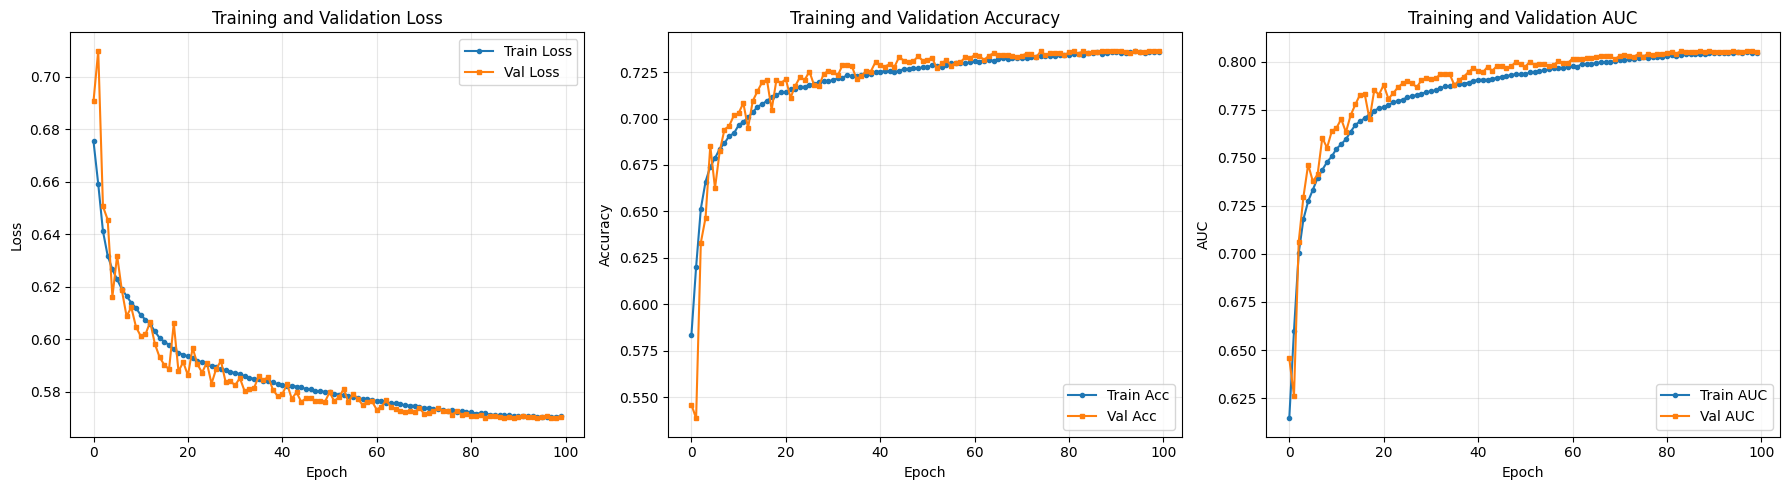

In [28]:
plot_training_history(history)

In [29]:
# ============================================================================
# Load Best Model and Evaluate on Test Set
# ============================================================================

# Load best model
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best validation AUC: {checkpoint['val_auc']:.4f}")

# Evaluate on test set
test_loss, test_acc, test_auc, test_preds, test_targets = evaluate(
    model, test_loader, criterion, device, phase='Test'
)

print("\n" + "=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC: {test_auc:.4f}")
print("=" * 80)

Loaded best model from epoch 88
Best validation AUC: 0.8057


Test:   0%|          | 0/1168 [00:00<?, ?it/s]

/tmp/ipykernel_23/3757676954.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=config.use_amp):



FINAL TEST RESULTS
Test Loss: 0.5681
Test Accuracy: 0.7383 (73.83%)
Test AUC: 0.8077


In [30]:
# ============================================================================
# ROC Curve and Performance Analysis
# ============================================================================

def plot_roc_curve(y_true, y_pred):
    """Plot ROC curve"""
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

    # Find optimal threshold (maximize Youden's J statistic)
    j_scores = tpr - fpr
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_tpr = tpr[optimal_idx]
    optimal_fpr = fpr[optimal_idx]

    plt.plot(optimal_fpr, optimal_tpr, 'ro', markersize=10,
             label=f'Optimal Threshold = {optimal_threshold:.3f}')

    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nOptimal threshold: {optimal_threshold:.4f}")
    print(f"TPR at optimal threshold: {optimal_tpr:.4f}")
    print(f"FPR at optimal threshold: {optimal_fpr:.4f}")

    return optimal_threshold

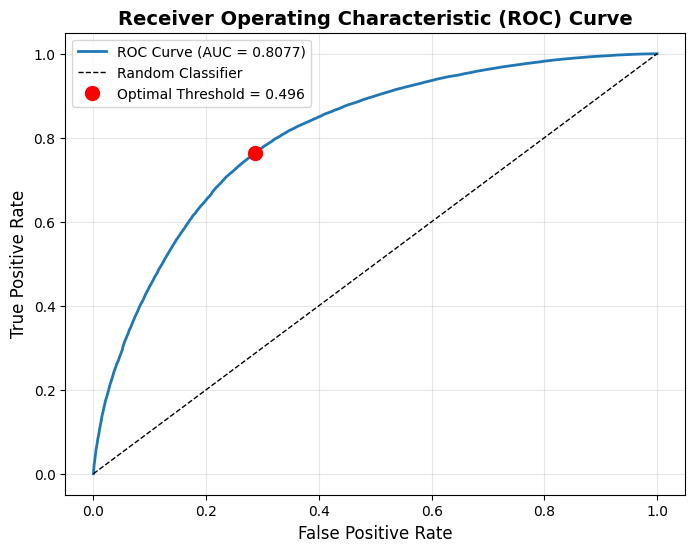


Optimal threshold: 0.4961
TPR at optimal threshold: 0.7645
FPR at optimal threshold: 0.2871

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

      Photon       0.75      0.71      0.73     37406
    Electron       0.73      0.76      0.74     37294

    accuracy                           0.74     74700
   macro avg       0.74      0.74      0.74     74700
weighted avg       0.74      0.74      0.74     74700


Confusion Matrix:
                Predicted
              Photon  Electron
Actual Photon    26670   10736
     Electron     8787   28507


In [31]:
optimal_threshold = plot_roc_curve(test_targets, test_preds)

# Confusion matrix at optimal threshold
from sklearn.metrics import confusion_matrix, classification_report

binary_preds_optimal = (test_preds > optimal_threshold).astype(float)

print("\nClassification Report (Optimal Threshold):")
print(classification_report(test_targets, binary_preds_optimal,
                          target_names=['Photon', 'Electron']))

cm = confusion_matrix(test_targets, binary_preds_optimal)
print("\nConfusion Matrix:")
print(f"                Predicted")
print(f"              Photon  Electron")
print(f"Actual Photon   {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"     Electron   {cm[1,0]:6d}  {cm[1,1]:6d}")

In [32]:
# ============================================================================
# Visualize Predictions
# ============================================================================

def visualize_predictions(model, dataset, device, num_samples=8):
    """Visualize model predictions on random samples"""
    model.eval()

    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label = dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            # Get prediction
            output = model(image_input)
            pred_prob = torch.sigmoid(output).item()
            pred_class = int(pred_prob > 0.5)

            # Plot energy channel
            img_display = image[0].cpu().numpy()  # Energy channel
            ax.imshow(img_display, cmap='hot')

            # Title with prediction
            true_label = 'Electron' if label == 1 else 'Photon'
            pred_label = 'Electron' if pred_class == 1 else 'Photon'
            color = 'green' if pred_class == label else 'red'

            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({pred_prob:.3f})',
                        color=color, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

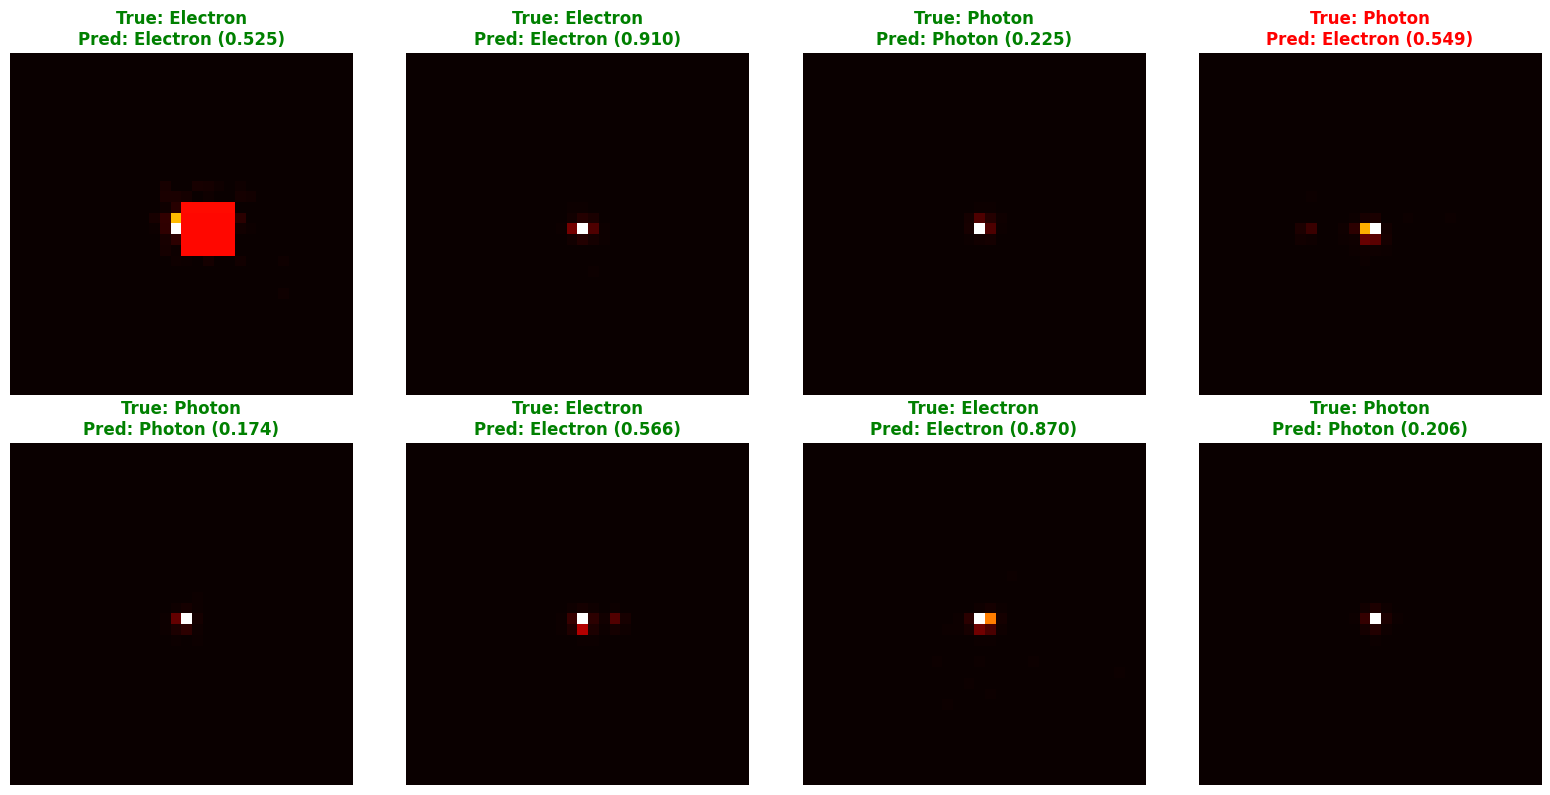

In [33]:
visualize_predictions(model, test_dataset, device)

In [34]:
# ============================================================================
# Save Final Model and Results
# ============================================================================

# Create a clean dictionary of the config (ignoring methods and internal vars)
config_dict = {}
try:
    for key in dir(config):
        if not key.startswith('_'):
            val = getattr(config, key)
            if not callable(val):
                config_dict[key] = val
except Exception:
    config_dict = {"info": "Could not extract config"}

results = {
    'test_auc': float(test_auc) if 'test_auc' in locals() else 0.0,
    'test_accuracy': float(test_acc) if 'test_acc' in locals() else 0.0,
    'optimal_threshold': float(optimal_threshold),
    'config': config_dict
}

import pickle
try:
    with open('training_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("Results saved successfully to 'training_results.pkl'")
except Exception as e:
    print(f"Warning: Could not save pickle file. Error: {e}")

# Save model for inference
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config_dict,
    'normalization': {'mean': mean, 'std': std},
    'optimal_threshold': optimal_threshold,
    'test_auc': test_auc
}, 'final_model.pth')

print("Final model saved to 'final_model.pth'")

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test AUC: {test_auc:.4f}")
print("=" * 80)

Results saved successfully to 'training_results.pkl'
Final model saved to 'final_model.pth'

TRAINING COMPLETE!
Final Test Accuracy: 73.83%
Final Test AUC: 0.8077


In [35]:
# ============================================================================
# Memory Cleanup
# ============================================================================

# Clear memory
del model, optimizer, scaler
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print("Memory cleaned up")
print(f"GPU Memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"GPU Memory reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

Memory cleaned up
GPU Memory allocated: 0.06 GB
GPU Memory reserved: 0.09 GB
